In [4]:
%pip install drain3 pandas

  Using cached drain3-0.9.11.tar.gz (27 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached jsonpickle-1.5.1-py2.py3-none-any.whl.metadata (6.6 kB)
  Using cached cachetools-4.2.1-py3-none-any.whl.metadata (4.6 kB)
Using cached cachetools-4.2.1-py3-none-any.whl (12 kB)
Using cached jsonpickle-1.5.1-py2.py3-none-any.whl (37 kB)
  Created wheel for drain3: filename=drain3-0.9.11-py3-none-any.whl size=24162 sha256=cab9dc1b2a2df72025e7d129f820a915715d1565f9bf556b2d3dd646fbf8c10a
  Stored in directory: c:\users\asus laptop\appdata\local\pip\cache\wheels\96\3f\bb\c2df80298168b46a45654266ac0c139220540689a17463e3cf
Successfully built drain3

   ---------------------------------------- 0/3 [jsonpickle]



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Phase 1

=== BẮT ĐẦU TUNING DRAIN_SIM_TH ===
Ngưỡng sim_th = 0.3:
 - Tổng số dòng log đã đọc: 2000
 - Số lượng Template sinh ra: 41
----------------------------------------
Ngưỡng sim_th = 0.5:
 - Tổng số dòng log đã đọc: 2000
 - Số lượng Template sinh ra: 48
----------------------------------------
Ngưỡng sim_th = 0.7:
 - Tổng số dòng log đã đọc: 2000
 - Số lượng Template sinh ra: 916
----------------------------------------


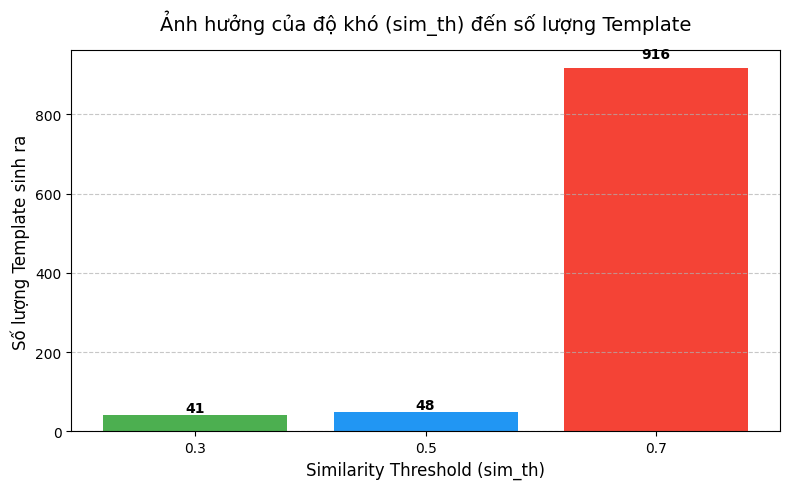

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig

def parse_and_evaluate(file_path, sim_th):
    config = TemplateMinerConfig()
    config.drain_sim_th = sim_th
    
    miner = TemplateMiner(config=config)
    
    total_lines = 0
    log_results = []
    
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            
            total_lines += 1
            result = miner.add_log_message(line)
            
            log_results.append({
                'template_id': result["cluster_id"],
                'template': result["template_mined"]
            })
            
    df = pd.DataFrame(log_results)
    template_counts = df.groupby(['template_id', 'template']).size().reset_index(name='count')
    template_counts = template_counts.sort_values(by='count', ascending=False)
    total_templates = len(template_counts)
    
    return total_lines, total_templates, template_counts

file_name = 'HDFS_2k.log'
thresholds = [0.3, 0.5, 0.7]
results_dict = {}
template_counts_list = [] 

print("=== BẮT ĐẦU TUNING DRAIN_SIM_TH ===")
for th in thresholds:
    lines, templates, df_counts = parse_and_evaluate(file_name, th)
    results_dict[th] = df_counts 
    template_counts_list.append(templates)
    
    print(f"Ngưỡng sim_th = {th}:")
    print(f" - Tổng số dòng log đã đọc: {lines}")
    print(f" - Số lượng Template sinh ra: {templates}")
    print("-" * 40)


plt.figure(figsize=(8, 5))
bars = plt.bar([str(t) for t in thresholds], template_counts_list, color=['#4CAF50', '#2196F3', '#F44336'])

plt.title('Ảnh hưởng của độ khó (sim_th) đến số lượng Template', fontsize=14, pad=15)
plt.xlabel('Similarity Threshold (sim_th)', fontsize=12)
plt.ylabel('Số lượng Template sinh ra', fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), int(yval), ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show() 

In [ ]:
BEST_TH = 0.5

best_df = results_dict[BEST_TH]

top_10_templates = best_df.head(10)

output_path = 'results/top_templates.csv'
top_10_templates.to_csv(output_path, index=False)

print(f"\nĐã xuất Top 10 Templates ra file: {output_path}")
print("Nội dung Top 5 để kiểm tra nhanh:")
print(top_10_templates.head(5))


Đã xuất Top 10 Templates ra file: results/top_templates.csv
Nội dung Top 5 để kiểm tra nhanh:
    template_id                                           template  count
2             1  <*> <*> <*> INFO dfs.DataNode$PacketResponder:...    286
6             2  <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* Name...    286
13            4  <*> <*> <*> INFO dfs.DataNode$DataXceiver: Rec...    268
10            3  <*> <*> <*> INFO dfs.DataNode$PacketResponder:...    260
21            7  <*> <*> <*> INFO dfs.FSDataset: Deleting block...    260


# Phase 2

In [7]:
import pandas as pd
import numpy as np
from datetime import datetime
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig

config = TemplateMinerConfig()
config.drain_sim_th = 0.5
miner = TemplateMiner(config=config)

log_entries = []
seen_templates = set()
new_template_alerts = []

print("=== 1. PARSING & DETECTING NEW TEMPLATES ===")
with open('HDFS_2k.log', 'r') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        
        parts = line.split()
        time_str = f"{parts[0]} {parts[1]}"
        try:
            timestamp = datetime.strptime(time_str, '%y%m%d %H%M%S')
        except:
            continue 
            
        result = miner.add_log_message(line)
        template_id = f"T-{result['cluster_id']:03d}"
        template_str = result['template_mined']
        
        if template_id not in seen_templates:
            seen_templates.add(template_id)
            new_template_alerts.append({
                'Time': timestamp,
                'Template_ID': template_id,
                'Template': template_str
            })
            
        log_entries.append({'timestamp': timestamp, 'template_id': template_id})

df_logs = pd.DataFrame(log_entries)
df_logs.set_index('timestamp', inplace=True)

ts_df = df_logs.groupby([pd.Grouper(freq='5min'), 'template_id']).size().unstack(fill_value=0)

print(f"Đã phát hiện {len(new_template_alerts)} New Templates xuất hiện lần đầu.")

for alert in new_template_alerts[:3]:
    print(f"[{alert['Time']}] {alert['Template_ID']} xuất hiện: {alert['Template']}")

=== 1. PARSING & DETECTING NEW TEMPLATES ===
Đã phát hiện 21 New Templates xuất hiện lần đầu.
[2008-11-09 20:36:15] T-001 xuất hiện: 081109 203615 148 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_38865049064139660 terminating
[2008-11-09 20:40:05] T-002 xuất hiện: 081109 204005 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864
[2008-11-09 20:46:55] T-003 xuất hiện: 081109 204655 556 INFO dfs.DataNode$PacketResponder: Received block blk_3587508140051953248 of size 67108864 from /10.251.42.84


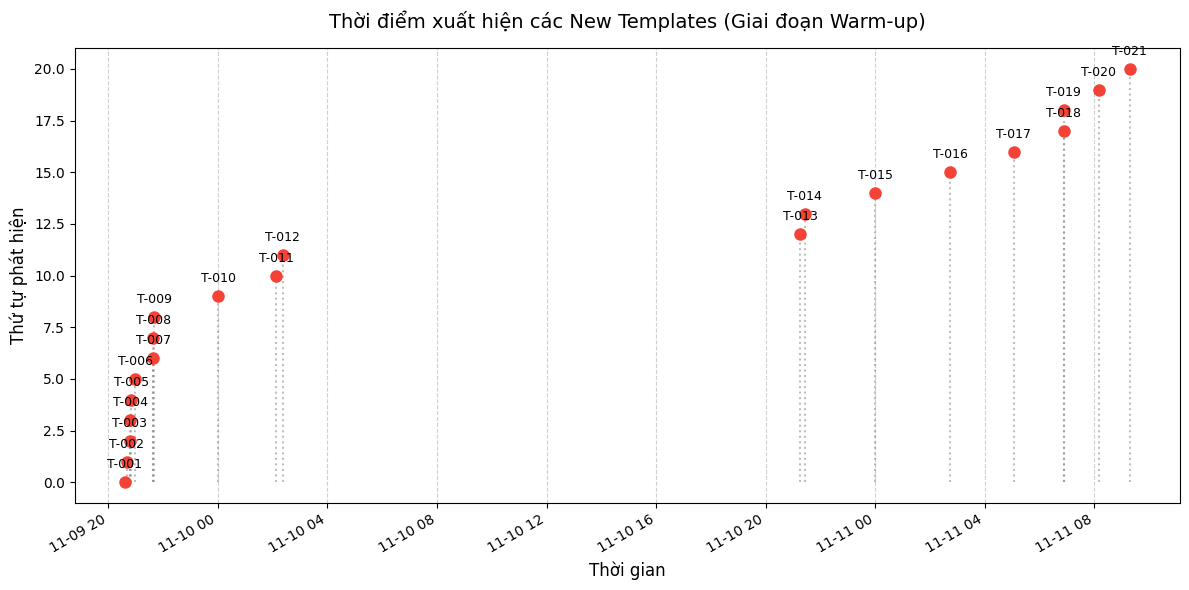

In [19]:
import matplotlib.pyplot as plt

if new_template_alerts:
    times = [alert['Time'] for alert in new_template_alerts]
    y_values = range(len(new_template_alerts)) 
    template_ids = [alert['Template_ID'] for alert in new_template_alerts]

    plt.figure(figsize=(12, 6))

    markerline, stemlines, baseline = plt.stem(times, y_values, linefmt=':', markerfmt='o', basefmt=' ')

    plt.setp(markerline, color='#F44336', markersize=8)
    plt.setp(stemlines, color='grey', alpha=0.5)

    for i, txt in enumerate(template_ids):
        plt.annotate(txt, (times[i], y_values[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

    plt.title('Thời điểm xuất hiện các New Templates (Giai đoạn Warm-up)', fontsize=14, pad=15)
    plt.xlabel('Thời gian', fontsize=12)
    plt.ylabel('Thứ tự phát hiện', fontsize=12)
    
    plt.gcf().autofmt_xdate() 
    
    plt.grid(True, linestyle='--', alpha=0.6, axis='x')
    plt.tight_layout()
    plt.show()
else:
    print("Không có New Template nào để vẽ biểu đồ.")

In [9]:
print("\n=== 2. DETECTING ANOMALIES (SPIKES) SỬ DỤNG 3-SIGMA ===")
spike_anomalies = []

for template_id in ts_df.columns:
    series = ts_df[template_id]
    
    mean_val = series.mean()
    std_val = series.std()

    threshold = mean_val + 3 * std_val
    
    spikes = series[series > threshold]
    
    for time_window, count in spikes.items():
        if count > 5:  
            spike_anomalies.append({
                'Time_Window': time_window,
                'Template_ID': template_id,
                'Count': count,
                'Normal_Mean': round(mean_val, 2),
                'Threshold': round(threshold, 2)
            })

df_spikes = pd.DataFrame(spike_anomalies)

if not df_spikes.empty:
    df_spikes = df_spikes.sort_values(by='Count', ascending=False)
    print(f"Phát hiện {len(df_spikes)} điểm bùng phát (Spikes):")
    print(df_spikes.head(10))
else:
    print("Hệ thống ổn định, không phát hiện Spike nào vượt ngưỡng 3-Sigma.")


=== 2. DETECTING ANOMALIES (SPIKES) SỬ DỤNG 3-SIGMA ===
Phát hiện 21 điểm bùng phát (Spikes):
           Time_Window Template_ID  Count  Normal_Mean  Threshold
13 2008-11-10 10:30:00       T-011     64         0.73      15.75
6  2008-11-10 10:35:00       T-007     45         0.86      14.68
14 2008-11-10 21:00:00       T-011     36         0.73      15.75
10 2008-11-11 04:45:00       T-007     32         0.86      14.68
8  2008-11-10 21:05:00       T-007     31         0.86      14.68
17 2008-11-11 04:40:00       T-011     25         0.73      15.75
11 2008-11-11 07:55:00       T-007     23         0.86      14.68
12 2008-11-11 09:00:00       T-007     22         0.86      14.68
9  2008-11-11 02:30:00       T-007     22         0.86      14.68
16 2008-11-11 02:30:00       T-011     22         0.73      15.75



Đang vẽ biểu đồ minh họa cho Template bùng phát mạnh nhất: T-011


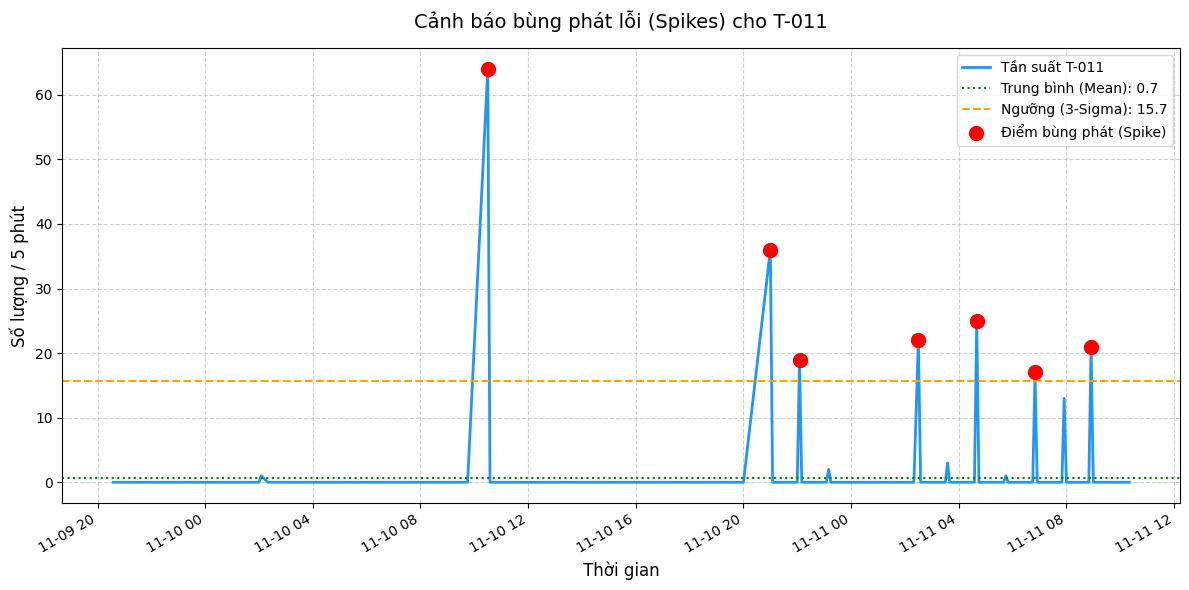

In [20]:
import matplotlib.pyplot as plt

if not df_spikes.empty:
    top_spike_template = df_spikes.iloc[0]['Template_ID']
    print(f"\nĐang vẽ biểu đồ minh họa cho Template bùng phát mạnh nhất: {top_spike_template}")
    
    series = ts_df[top_spike_template]
    
    mean_val = series.mean()
    std_val = series.std()
    threshold = mean_val + 3 * std_val

    spike_points = series[series > threshold]
    
    plt.figure(figsize=(12, 6))

    plt.plot(series.index, series.values, label=f'Tần suất {top_spike_template}', color='#2196F3', linewidth=2)

    plt.axhline(y=mean_val, color='green', linestyle=':', label=f'Trung bình (Mean): {mean_val:.1f}')

    plt.axhline(y=threshold, color='orange', linestyle='--', label=f'Ngưỡng (3-Sigma): {threshold:.1f}')

    plt.scatter(spike_points.index, spike_points.values, color='red', s=100, zorder=5, label='Điểm bùng phát (Spike)')

    plt.title(f'Cảnh báo bùng phát lỗi (Spikes) cho {top_spike_template}', fontsize=14, pad=15)
    plt.xlabel('Thời gian', fontsize=12)
    plt.ylabel('Số lượng / 5 phút', fontsize=12)
    plt.legend()

    plt.gcf().autofmt_xdate()
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Không có điểm bùng phát nào để vẽ biểu đồ.")

# Phase 3

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("=== 1. TF-IDF & SIMILARITY MATRIX ===")

templates = []
template_ids = []
for cluster in miner.drain.clusters:
    templates.append(cluster.get_template())
    template_ids.append(f"T-{cluster.cluster_id:03d}")

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(templates)
sim_matrix = cosine_similarity(tfidf_matrix)

print("Các cụm Template có nội dung tương đồng cao (>50%):")
found_cluster = False

for i in range(len(templates)):
    for j in range(i + 1, len(templates)):
        score = sim_matrix[i, j]
        if score > 0.5:
            print(f"\n🔹 Cặp {template_ids[i]} & {template_ids[j]} (Độ giống: {score*100:.1f}%)")
            print(f"   - {templates[i]}")
            print(f"   - {templates[j]}")
            found_cluster = True

if not found_cluster:
    print("Không có cụm nào vượt ngưỡng tương đồng.")

=== 1. TF-IDF & SIMILARITY MATRIX ===
Các cụm Template có nội dung tương đồng cao (>50%):

🔹 Cặp T-003 & T-017 (Độ giống: 50.9%)
   - <*> <*> <*> INFO dfs.DataNode$PacketResponder: Received block <*> of size <*> from <*>
   - 081111 <*> <*> INFO dfs.DataNode$DataXceiver: Received block <*> src: <*> dest: <*> of size 67108864

🔹 Cặp T-004 & T-017 (Độ giống: 54.9%)
   - <*> <*> <*> INFO dfs.DataNode$DataXceiver: Receiving block <*> src: <*> dest: <*>
   - 081111 <*> <*> INFO dfs.DataNode$DataXceiver: Received block <*> src: <*> dest: <*> of size 67108864

🔹 Cặp T-005 & T-010 (Độ giống: 71.4%)
   - 081109 <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: <*> <*>
   - 081110 <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: <*> <*>

🔹 Cặp T-005 & T-016 (Độ giống: 74.6%)
   - 081109 <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: <*> <*>
   - 081111 <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: <*> <*>

🔹 Cặp T-008 & T-012 (Độ gi

In [17]:
import random

print("\n=== 2. INJECT DÒNG LOG LẠ & PHÁT HIỆN NEW TEMPLATE ===")

fake_log = "081109 220000 123 FATAL ERROR! The Matrix has glitching, Neo is escaping the simulation"
print(f"Dòng log bị tiêm vào: '{fake_log}'")

result = miner.add_log_message(fake_log)

if result["change_type"] == "cluster_created":
    print("\nKẾT QUẢ: HỆ THỐNG ĐÃ PHÁT HIỆN SỰ XÂM NHẬP!")
    print(f"   - Phân loại: NEW TEMPLATE DETECTED")
    print(f"   - Template ID mới được cấp: T-{result['cluster_id']:03d}")
    print(f"   - Khuôn mẫu trích xuất được: {result['template_mined']}")
else:
    print("\nTHẤT BẠI: Hệ thống đã gộp dòng log lạ vào một template cũ.")
    print(f"Dòng log lạ đã bị gộp vào Template ID: T-{result['cluster_id']:03d}")
    print(f"Nội dung của Template đó là: {result['template_mined']}")


=== 2. INJECT DÒNG LOG LẠ & PHÁT HIỆN NEW TEMPLATE ===
Dòng log bị tiêm vào: '081109 220000 123 FATAL ERROR! The Matrix has glitching, Neo is escaping the simulation'

THẤT BẠI: Hệ thống đã gộp dòng log lạ vào một template cũ.
Dòng log lạ đã bị gộp vào Template ID: T-023
Nội dung của Template đó là: 081109 220000 123 FATAL ERROR! The Matrix has glitching, Neo is escaping the simulation
